# Calcolo della f0 su tutto il dataset

In [268]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
import json
import emcee
from scipy.special import logsumexp
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.lines as mlines


In [244]:
%matplotlib widget
plt.close('all')

Abbiamo alcune opzioni da confrontare per il calcolo della f0, tra cui:
- primo picco dello spettro di potenza
- gcd approx
- regressione lineare
- bayesiano

In [245]:
def get_f0_first_peak(peak_freqs, freqs, spectrum):
    return peak_freqs[0] if len(peak_freqs) > 0 else None


def get_f0_from_gcd(peak_freqs):

    if len(peak_freqs) < 2:
        return None

    peak_freqs = np.sort(peak_freqs)[:6]

    reference_peak = peak_freqs[0]

    best_f0 = reference_peak
    best_score = float('inf')

    for n in range(1, 7):
        f0_candidate = reference_peak / n
        
        residuals = [np.abs(f / f0_candidate - round(f / f0_candidate)) for f in peak_freqs]
        
        avg_error = np.mean(residuals)

        if avg_error < 0.05:
            return f0_candidate

        if avg_error < best_score:
            best_score = avg_error
            best_f0 = f0_candidate
            
    return best_f0


def get_f0_linear_regression(peak_freqs, peak_mags):

    if len(peak_freqs) < 2 or len(peak_mags) < 2:
        return None

    top_indices = np.argsort(peak_mags)[-6:]
    top_freqs = np.sort(peak_freqs[top_indices]) 

    rough_f0 = top_freqs[0]

    x = np.round(top_freqs / rough_f0)
    y = top_freqs

    valid = x > 0
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return rough_f0

    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0] 
    
    return m  

In [246]:
def get_limiti_prior(observed_freqs):

    f_min = np.min(observed_freqs) * 0.2
    f_max = np.min(observed_freqs) * 3

    log_sigma_min = np.log(0.1)
    log_sigma_max = np.log(100)

    log_uniform = -np.log(f_max - f_min)

    return f_min, f_max, log_sigma_min, log_sigma_max, log_uniform


In [247]:
def compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, ns, alpha=0.6, eps=1e-8):

    ns = np.asarray(ns)
    peak_freqs = np.asarray(peak_freqs)
    peak_mags = np.asarray(peak_mags)
   
    f0_guess = float(peak_freqs[0])

    env = np.zeros_like(ns, dtype=float)
    for fk, mk in zip(peak_freqs, peak_mags):
        if fk <= 0 or mk <= 0:
            continue
        n_est = int(np.round(fk / f0_guess))
        if 1 <= n_est <= ns[-1]:
            env[n_est - 1] += mk

    weights = (env + eps) * np.exp(-alpha * (ns - 1).astype(float))
    weights = weights / np.sum(weights)

    return np.log(weights)


In [248]:
def get_f0_bayesian_map(peak_freqs, peak_mags):

    f_min, f_max, log_sigma_min, log_sigma_max, log_uniform = get_limiti_prior(peak_freqs)

    # Parametri delle armoniche
    ns = np.arange(1, 21)   # Consideriamo le prime 20 armoniche
    P_n_log = compute_P_n_log_magnitude_aware(peak_freqs, peak_mags, np.arange(1,21))
    U_log = log_uniform # Probabilità uniforme del rumore
    q_min = 0
    q_max = 1

    def log_prob(theta):

        f0, log_sigma, q = theta
        sigma = np.exp(log_sigma)

        if not (f_min < f0 < f_max and log_sigma_min < log_sigma < log_sigma_max and q_min < q < q_max):
            return -1e15

        total_log_likelihood = 0.0

        for fk in peak_freqs:

            log_gaussians = -0.5 * ((fk - ns * f0) / sigma)**2 - log_sigma - 0.5 * np.log(2 * np.pi)
            
            log_p_harmonics = logsumexp(log_gaussians + P_n_log)

            log_p_total = np.logaddexp(np.log(q) + log_p_harmonics, np.log(1 - q) + U_log)
            
            total_log_likelihood += log_p_total

        return total_log_likelihood

    f_start = float(peak_freqs[0])  

    sigma_start = np.log(0.1*f_start)  

    q_start = 0.8

    x0 = [f_start, sigma_start, q_start]

    res = sp.optimize.minimize(
        lambda t: -log_prob(t),
        x0=x0,
        method='L-BFGS-B',
        bounds=[
            (f_min, f_max),
            (log_sigma_min, log_sigma_max),
            (q_min, q_max)
        ],
        options={'maxiter': 300}
    )

    f0_map, log_sigma_map, q_map = res.x
    q_map = float(np.clip(q_map, q_min, q_max))
    print(f"MAP Singolo -> F0: {f0_map:.2f}Hz, Sigma: {np.exp(log_sigma_map):.5f}Hz, q: {q_map:.8f}")

    return f0_map, q_map

In [249]:
base_dir = "dati_processati"
peak_file = "spettri_peaks.json"

filepath = os.path.join(base_dir, peak_file)

with open(filepath, 'r') as f:
    peaks_dict = json.load(f)


In [250]:

f0_results = {}
bayesian_q_results = {}
for sample, data in peaks_dict.items():
    print(f"Processing {sample}...")
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])

    bayesian_map_result = get_f0_bayesian_map(freqs, mags)
    if bayesian_map_result is None:
        bayesian_map_f0 = None
        bayesian_map_q = None
    else:
        bayesian_map_f0, bayesian_map_q = bayesian_map_result

    f0_results[sample] = {
        'first_peak': get_f0_first_peak(freqs, freqs, mags),
        'gcd': get_f0_from_gcd(freqs),
        'linear_regression': get_f0_linear_regression(freqs, mags),
        #'bayesian': get_f0_bayesian(freqs),
        'bayesian_map': bayesian_map_f0
    }
    bayesian_q_results[sample] = bayesian_map_q

Processing Nota_1...
MAP Singolo -> F0: 1563.32Hz, Sigma: 0.52514Hz, q: 0.27606907
Processing Nota_2...
MAP Singolo -> F0: 1481.89Hz, Sigma: 0.10000Hz, q: 0.51746253
Processing Nota_3...
MAP Singolo -> F0: 329.82Hz, Sigma: 0.13984Hz, q: 0.17111212
Processing Nota_4...
MAP Singolo -> F0: 174.17Hz, Sigma: 0.52469Hz, q: 0.03294438
Processing Nota_5...
MAP Singolo -> F0: 220.74Hz, Sigma: 0.10000Hz, q: 0.04482020
Processing Nota_6...
MAP Singolo -> F0: 467.21Hz, Sigma: 0.29161Hz, q: 0.01096920
Processing Nota_7...
MAP Singolo -> F0: 175.08Hz, Sigma: 0.10000Hz, q: 0.27421279
Processing Nota_8...
MAP Singolo -> F0: 783.04Hz, Sigma: 0.48299Hz, q: 0.21468002
Processing Nota_9...
MAP Singolo -> F0: 155.91Hz, Sigma: 0.10000Hz, q: 0.25711334
Processing Nota_10...
MAP Singolo -> F0: 233.05Hz, Sigma: 0.10035Hz, q: 0.02908592
Processing Nota_11...
MAP Singolo -> F0: 1399.80Hz, Sigma: 0.10000Hz, q: 0.38194530
Processing Nota_12...
MAP Singolo -> F0: 1178.20Hz, Sigma: 0.10000Hz, q: 0.12493362
Processin

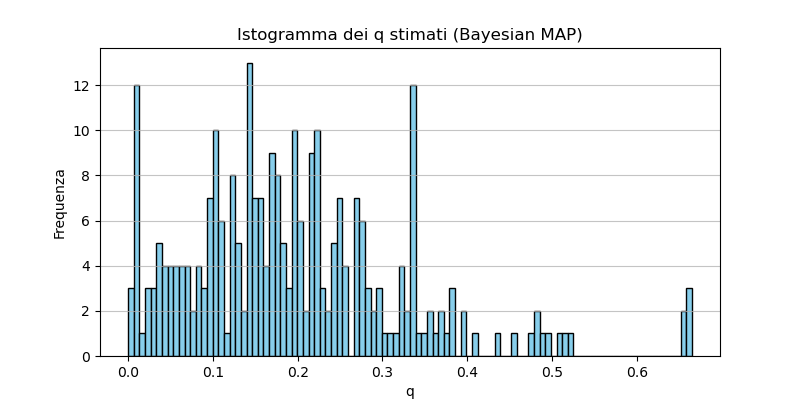

In [251]:
# istogramma delle q_map stimate con il metodo bayesiano
bayesian_qs = [q for q in bayesian_q_results.values() if q is not None]
plt.figure(figsize=(8, 4))
plt.hist(bayesian_qs, bins=100, color='skyblue', edgecolor='black')
plt.title('Istogramma dei q stimati (Bayesian MAP)')
plt.xlabel('q')
plt.ylabel('Frequenza')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [252]:
for sample, results in f0_results.items():
    print(f"{sample}:")
    for method, f0 in results.items():
        print(f"  {method}: {f0}")

Nota_1:
  first_peak: 1562.6370790865697
  gcd: 1562.6370790865697
  linear_regression: 1563.2043538336848
  bayesian_map: 1563.3232555580682
Nota_2:
  first_peak: 1481.8912352831248
  gcd: 1481.8912352831248
  linear_regression: 1481.8912352831242
  bayesian_map: 1481.891235288313
Nota_3:
  first_peak: 329.8213467704993
  gcd: 329.8213467704993
  linear_regression: 330.66507579712163
  bayesian_map: 329.8170749748264
Nota_4:
  first_peak: 173.30582447230597
  gcd: 173.30582447230597
  linear_regression: 371.12121609406375
  bayesian_map: 174.17129463235202
Nota_5:
  first_peak: 220.73956801990275
  gcd: 220.73956801990275
  linear_regression: 220.73956801990258
  bayesian_map: 220.7395679949746
Nota_6:
  first_peak: 467.2118809894135
  gcd: 467.2118809894135
  linear_regression: 467.2118809894131
  bayesian_map: 467.2118809894135
Nota_7:
  first_peak: 175.08024511234316
  gcd: 175.08024511234316
  linear_regression: 175.08024511234305
  bayesian_map: 175.08024362518015
Nota_8:
  first

In [253]:
note_freqs = {}
for octave in range(1, 7):  # 1..8
    for i, note in enumerate(["DO", "DO#", "RE", "RE#", "MI", "FA", "FA#", "SOL", "SOL#", "LA", "LA#", "SI"]):
        freq = 16.35 * (2 ** octave) * (2 ** (i / 12))
        note_freqs[f"{note}{octave}"] = freq

print("Frequenze delle note:")
for note, freq in sorted(note_freqs.items()):
    print(f"  {note}: {freq:.2f} Hz")

Frequenze delle note:
  DO#1: 34.64 Hz
  DO#2: 69.29 Hz
  DO#3: 138.58 Hz
  DO#4: 277.16 Hz
  DO#5: 554.31 Hz
  DO#6: 1108.62 Hz
  DO1: 32.70 Hz
  DO2: 65.40 Hz
  DO3: 130.80 Hz
  DO4: 261.60 Hz
  DO5: 523.20 Hz
  DO6: 1046.40 Hz
  FA#1: 46.24 Hz
  FA#2: 92.49 Hz
  FA#3: 184.98 Hz
  FA#4: 369.96 Hz
  FA#5: 739.92 Hz
  FA#6: 1479.83 Hz
  FA1: 43.65 Hz
  FA2: 87.30 Hz
  FA3: 174.60 Hz
  FA4: 349.19 Hz
  FA5: 698.39 Hz
  FA6: 1396.78 Hz
  LA#1: 58.26 Hz
  LA#2: 116.53 Hz
  LA#3: 233.06 Hz
  LA#4: 466.12 Hz
  LA#5: 932.24 Hz
  LA#6: 1864.47 Hz
  LA1: 54.99 Hz
  LA2: 109.99 Hz
  LA3: 219.98 Hz
  LA4: 439.96 Hz
  LA5: 879.91 Hz
  LA6: 1759.83 Hz
  MI1: 41.20 Hz
  MI2: 82.40 Hz
  MI3: 164.80 Hz
  MI4: 329.60 Hz
  MI5: 659.19 Hz
  MI6: 1318.38 Hz
  RE#1: 38.89 Hz
  RE#2: 77.77 Hz
  RE#3: 155.55 Hz
  RE#4: 311.10 Hz
  RE#5: 622.19 Hz
  RE#6: 1244.39 Hz
  RE1: 36.70 Hz
  RE2: 73.41 Hz
  RE3: 146.82 Hz
  RE4: 293.64 Hz
  RE5: 587.27 Hz
  RE6: 1174.54 Hz
  SI1: 61.73 Hz
  SI2: 123.46 Hz
  SI3: 246

In [254]:
types = [
    "first_peak",
    "gcd",
    "linear_regression",
    #"bayesian",
    "bayesian_map"
]

# separa i risultati per metodo e rimiovi i None
method_results = {method: [] for method in types}
for sample, results in f0_results.items():
    for method in types:
        method_results[method].append(results[method])

# rimuovi i None values
for method in types:
    method_results[method] = [freq for freq in method_results[method] if freq is not None]


# binning dei risultati nelle note più vicine
def find_closest_note(freq, note_freqs):
    closest_note = None
    min_diff = float('inf')
    for note, note_freq in note_freqs.items():
        diff = abs(freq - note_freq)
        if diff < min_diff:
            min_diff = diff
            closest_note = note
    return closest_note

binned_results = {method: [] for method in types}
for method in types:
    for freq in method_results[method]:
        if freq is not None:
            closest_note = find_closest_note(freq, note_freqs)
            binned_results[method].append(closest_note)
        else:
            binned_results[method].append(None)



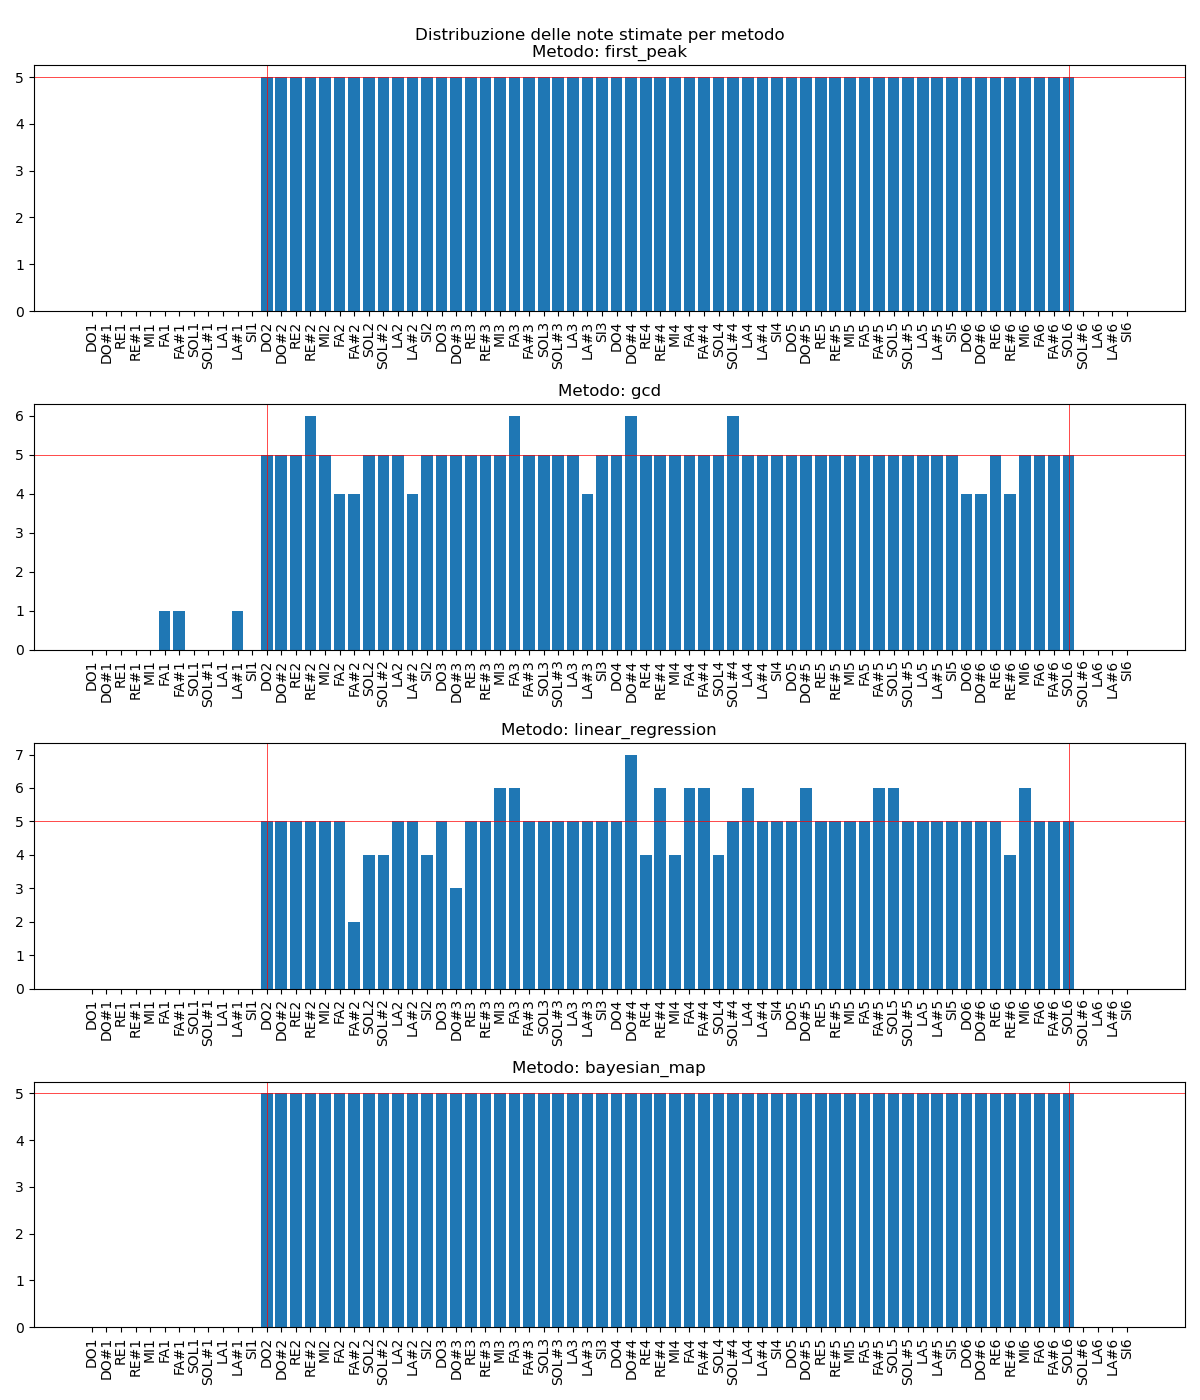

In [255]:
ordered_notes = list(note_freqs.keys())
fig, axs = plt.subplots(len(types), 1, figsize=(12, 14))

fig.suptitle("Distribuzione delle note stimate per metodo")

for i, method in enumerate(types):
    counts = [binned_results[method].count(note) for note in ordered_notes]
    axs[i].bar(np.arange(len(ordered_notes)), counts, width=0.8)
    axs[i].set_title(f"Metodo: {method}")
    axs[i].set_xticks(np.arange(len(ordered_notes)))
    axs[i].set_xticklabels(ordered_notes, rotation=90)
    axs[i].axhline(5, color='red', linewidth=0.5)
    if "DO2" in ordered_notes:
        axs[i].axvline(ordered_notes.index("DO2"), color='red', linewidth=0.5)
    if "SOL6" in ordered_notes:
        axs[i].axvline(ordered_notes.index("SOL6"), color='red', linewidth=0.5)


plt.tight_layout()
plt.show()


In [288]:
def estrai_armoniche_reali(f0, peak_freqs, peak_mags, num_armoniche=6, tolleranza=0.05):
    """
    Data una fondamentale f0, cerca tra i peak_freqs le armoniche corrispondenti.
    Restituisce due liste: le frequenze e le magnitudini delle armoniche trovate.
    Se un'armonica manca, inserisce None.
    """
    if f0 is None:
        return [], []
        
    armoniche_freqs = []
    armoniche_mags = []
    
    for n in range(1, num_armoniche + 1):
        # Calcoliamo la frequenza teorica perfetta (es. 440, 880, 1320...)
        freq_teorica = f0 * n
        
        # Troviamo il picco reale più vicino a questa frequenza teorica
        distanze = np.abs(peak_freqs - freq_teorica)
        idx_vicino = np.argmin(distanze)
        
        # Controlliamo se è un "vero" match o solo un picco a caso molto lontano
        # Usiamo una tolleranza percentuale (es. entro il 5% della frequenza teorica)
        errore_relativo = distanze[idx_vicino] / freq_teorica
        
        if errore_relativo < tolleranza:
            armoniche_freqs.append(peak_freqs[idx_vicino])
            armoniche_mags.append(peak_mags[idx_vicino])
        else:
            # L'armonica non è stata catturata dal microfono o è coperta dal rumore
            armoniche_freqs.append(None)
            armoniche_mags.append(None)
            
    return armoniche_freqs, armoniche_mags


armoniche_results = {}

for sample, data in peaks_dict.items():
    freqs = np.array(data["peaks"]['frequencies'])
    mags = np.array(data["peaks"]['magnitudes'])
    
    f0_corrente = f0_results[sample]['bayesian_map']

    arm_freqs, arm_mags = estrai_armoniche_reali(f0_corrente, freqs, mags, num_armoniche=6)
    
    armoniche_results[sample] = {
        'f0': f0_corrente,
        'frequenze': arm_freqs,
        'magnitudini': arm_mags
    }

print("Finito! Tutte le armoniche sono state salvate.")


Finito! Tutte le armoniche sono state salvate.


In [289]:
features = []
sample_names = []

for sample, results in armoniche_results.items():
    mags = results['magnitudini']
    
    fundamental_power = mags[0]
    
    if fundamental_power is None or fundamental_power <= 0:
        continue

    row_db = []
    for m in mags:
        if m is None or m <= 0:
            row_db.append(-80.0)
        else:
            val_db = 10 * np.log10(m / fundamental_power)
            row_db.append(val_db)
            
    features.append(row_db)
    sample_names.append(sample)

data = np.array(features)

# Numero di registri prefissato
n_clusters = 5

kmeans = KMeans(n_clusters = n_clusters,
                init = "random",
                n_init = 10000,  
                copy_x = True,
                algorithm = "lloyd").fit(data)

print("Clustering completato!")


Clustering completato!


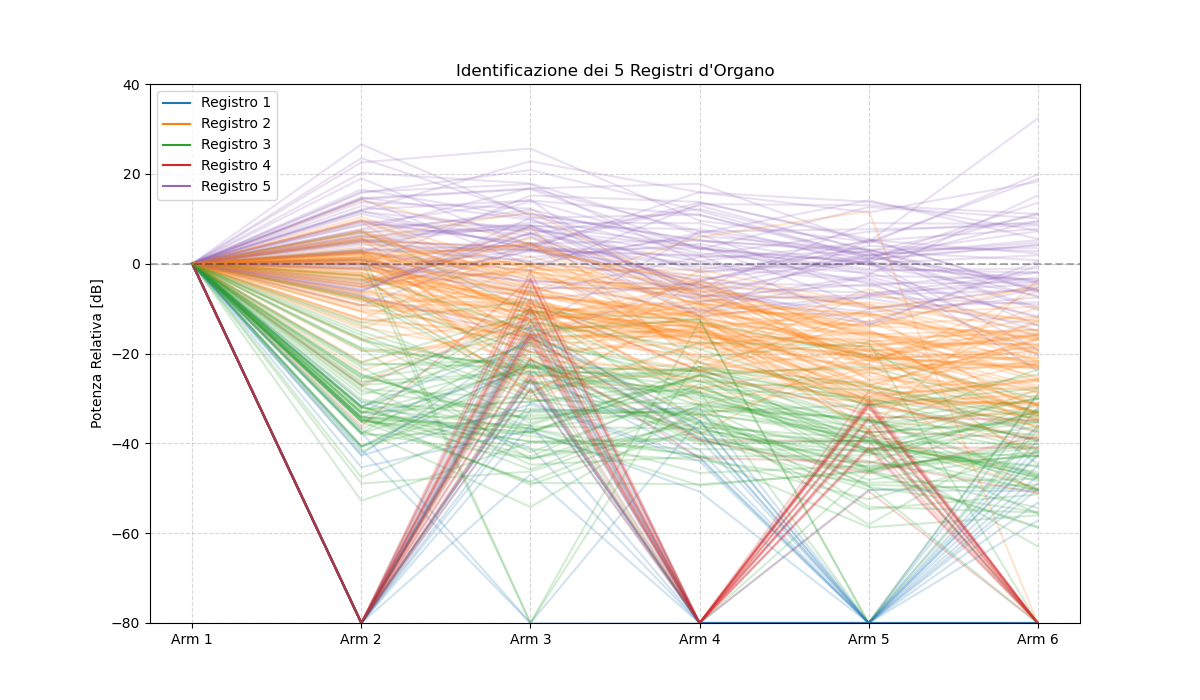

In [290]:
# Prepariamo il DataFrame per il plot
columns = [f"Arm {i}" for i in range(1, 7)]
database = pd.DataFrame(data, columns=columns)
database["Cluster"] = kmeans.labels_

# Setup colori
cmap = plt.get_cmap("tab10")
manual_selection = {i: cmap(i) for i in range(5)}
handles = [mlines.Line2D([], [], color=manual_selection[i], label=f"Registro {i+1}") for i in range(5)]

# Plot
plt.figure(figsize=(12, 7))
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.2)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Linea della fondamentale
plt.ylabel("Potenza Relativa [dB]")
plt.title("Identificazione dei 5 Registri d'Organo")
plt.ylim(-80, 40) # Visualizziamo dai -80dB allo 0 (e un po' sopra per margine)
plt.legend(handles=handles)
plt.grid(linestyle="--", alpha=0.5)
plt.show()

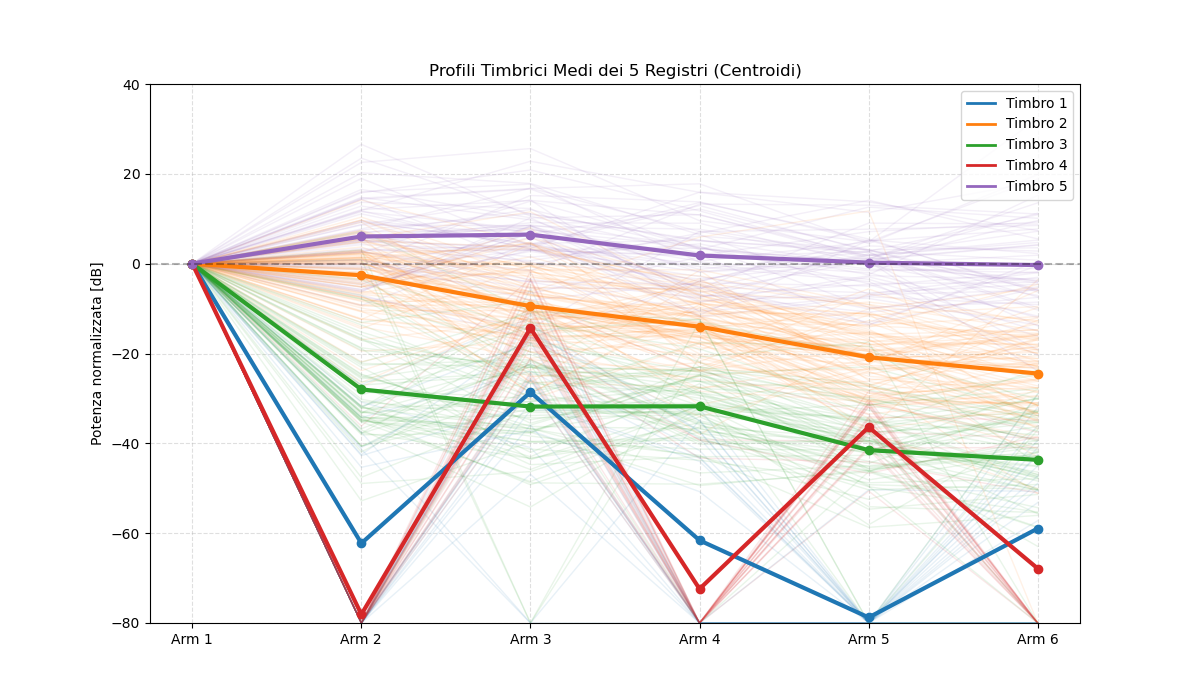

In [291]:
centroids = kmeans.cluster_centers_ 

# Creiamo un DataFrame per i centroidi usando le stesse 'columns' delle armoniche
db_centroids = pd.DataFrame(centroids, columns=columns)
db_centroids["Timbro_ID"] = [0, 1, 2, 3, 4] 

# 2. Setup della Legenda
handles = [
    mlines.Line2D([], [], color=manual_selection[i], label=f"Timbro {i+1}", linewidth=2)
    for i in range(5)
]

plt.figure(figsize=(12, 7))

# 3. Disegniamo lo sfondo: tutte le singole note (alpha molto basso)
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.1, linewidth=1)

for i, row in db_centroids.iterrows():
    plt.plot(columns, row[columns], 
             color=manual_selection[int(row["Timbro_ID"])], 
             linewidth=3, 
             marker='o', 
             markersize=6)

# 5. Formattazione finale
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.ylabel("Potenza normalizzata [dB]")
plt.title("Profili Timbrici Medi dei 5 Registri (Centroidi)")
plt.ylim(-80, 40) 
plt.margins(x=0.05)
plt.legend(handles=handles, loc='upper right')
plt.grid(linestyle="--", alpha=0.4)

plt.show()